## boundary Attack Method
### brief explanation 
- boundary attack is a black-box adversarial attack that starts with an adversarial example and iterates tomakeit closer to the original image while keeping it adversarial.
- It is a black-box attack because it does not require knowlage about the internal structure or the gradiants of the model.
- it makes sure to be as close as possible to the original image while keeping the wrong prediction 


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import Utils as utils
import boundary as boundary

2025-02-02 15:25:54.657409: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-02 15:25:54.680905: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-02 15:25:54.688748: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-02 15:25:54.706001: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-02 15:25:56.209679: W tensorflow/compiler/tf2

In [2]:
#load the model
model = tf.keras.models.load_model('../efficientNetB1_CIFAR10_Augmented.keras')


In [3]:
#read the images
original_image = utils.read_image('../Collected_Data/bird/25.jpeg', (240, 240))
Adversarial_image =  utils.read_image("../Adversarial_Images/pgd/bird_pgd.png",(240,240))

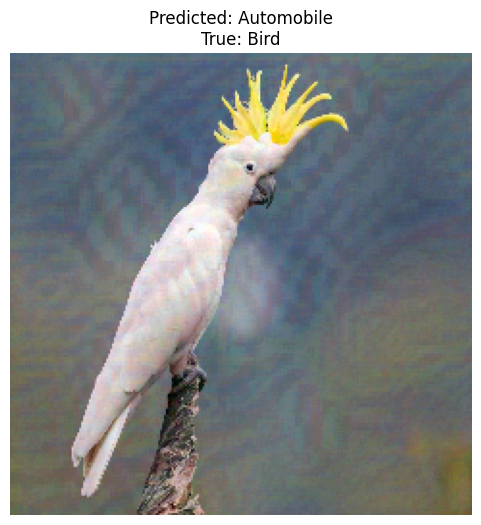

Top 1% Predictions:
  Automobile: 100.00%


In [4]:
utils.predict_and_plot(model, Adversarial_image, 2)

In [6]:
Adversarial_image_boundary, min_perturbation = boundary.boundary_attack_single_image(model, original_image, Adversarial_image, 2, max_iter=1000, epsilon=0.01, step_size=0.1)

Iteration 0: Distance to original = 2097.609375
Iteration 1: Distance to original = 1887.85205078125
Iteration 2: Distance to original = 1699.0582275390625
Iteration 3: Distance to original = 1529.15185546875
Iteration 4: Distance to original = 1376.2310791015625
Iteration 5: Distance to original = 1238.615478515625
Iteration 6: Distance to original = 1114.7476806640625
Iteration 7: Distance to original = 1003.2764282226562
Iteration 8: Distance to original = 902.95166015625
Iteration 9: Distance to original = 812.656982421875
Iteration 10: Distance to original = 731.38671875
Iteration 11: Distance to original = 658.2528076171875
Iteration 12: Distance to original = 592.4259643554688
Iteration 13: Distance to original = 533.1834716796875
Iteration 14: Distance to original = 479.8618469238281
Iteration 15: Distance to original = 431.8773498535156
Iteration 16: Distance to original = 388.6902160644531
Iteration 17: Distance to original = 349.8209228515625
Iteration 18: Distance to origin

In [38]:
#apply the boundary attack again with vary small step size to make sure that the image is as close as possible to the original image
Adversarial_image_boundary, min_perturbation = boundary.boundary_attack_single_image(model, original_image, Adversarial_image_boundary, 2, max_iter=1000, epsilon=0.01, step_size=0.001)

Iteration 0: Distance to original = 314.52154541015625
Iteration 1: Distance to original = 314.2095947265625
Iteration 2: Distance to original = 313.8955993652344
The minimum perturbation is found


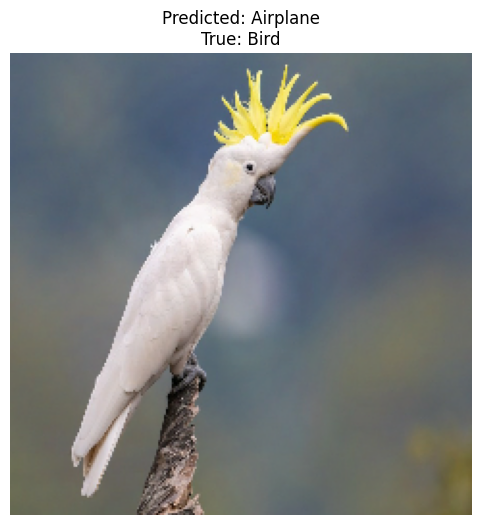

Top 1% Predictions:
  Airplane: 49.85%


In [42]:
utils.predict_and_plot(model, Adversarial_image_boundary, 2)

In [7]:
import Utils as utils
#save the adversarial image
utils.save_image(Adversarial_image, '../Adversarial_Images/pgd/bird_pgd.png')